# Linear Probe: Do Averaged Embeddings Preserve Linguistic Structure?

**Experiment:** Train a linear classifier on:
1. **Individual** token embeddings `e(t_i)`
2. **Averaged** embeddings `avg(e(t_i), e(t_{i+1}))` for k=2
3. **Averaged** embeddings for k=4

Predict: POS tags and NER labels from CoNLL-2003.

If accuracy drops significantly → averaging loses linguistic structure.  
If accuracy holds → the transformer can still work with averaged representations.

In [59]:
# Install dependencies if needed
import subprocess, sys
for pkg in ["datasets", "scikit-learn", "seqeval"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"])

You should consider upgrading via the '/Users/vardh/token-averaging/venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/vardh/token-averaging/venv/bin/python -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/vardh/token-averaging/venv/bin/python -m pip install --upgrade pip' command.


In [60]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from datasets import load_dataset
from transformers import AutoTokenizer


ROOT = Path().resolve().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.shared.olm_model import OLMTransformerBody
from experiments.chinchilla.model_configs import MODEL_CONFIGS

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")

device: cpu


## 1. Load Embedding Weights from Checkpoint

In [61]:
# ── Config ───────────────────────────────────────────────────────────────────
MODEL_NAME   = "model1_50m"   # change to any trained model
RESULTS_DIR  = Path("./results")

cfg = MODEL_CONFIGS[MODEL_NAME]

def load_embedding_matrix(model_name: str, results_dir: Path) -> torch.Tensor:
    """
    Load the token embedding weight matrix [vocab_size, d_model] from the
    latest checkpoint.  Falls back to random initialisation if no checkpoint
    is found (useful for a random-baseline control).
    """
    cfg = MODEL_CONFIGS[model_name]

    # Build skeleton model (no GPU needed — we only want the embedding table)
    backbone = OLMTransformerBody(
        vocab_size=50_277,
        d_model=cfg.d_model,
        n_heads=cfg.n_heads,
        n_layers=cfg.n_layers,
        context_length=cfg.context_len,
    )

    ckpt_dir = results_dir / model_name / "checkpoints"
    ckpts    = sorted(ckpt_dir.glob("step_*.pt")) if ckpt_dir.exists() else []
    final    = ckpt_dir / "final.pt" if ckpt_dir.exists() else None

    print(f"ckpts: {ckpts}")
    print(f"final: {final}")
    print(f"ckpt_dir: {ckpt_dir}")
    if final and final.exists():
        chosen = final
    elif ckpts:
        chosen = ckpts[-1]   # latest step
    else:
        print(f"[warn] No checkpoint found for {model_name} — using random init.")
        return backbone.embed_in.embedding.weight.detach().cpu()

    print(f"Loading checkpoint: {chosen}")
    state = torch.load(chosen, map_location="cpu")

    # State dict may be wrapped in 'model' key or DDP-prefixed
    sd = state.get("model", state)
    sd = {k.replace("module.", "").replace("backbone.", ""): v for k, v in sd.items()}

    backbone.load_state_dict(sd, strict=False)
    return backbone.embed_in.embedding.weight.detach().cpu()


emb_matrix = load_embedding_matrix(MODEL_NAME, RESULTS_DIR)
print(f"Embedding matrix: {emb_matrix.shape}  (vocab × d_model)")

ckpts: []
final: results/model1_50m/checkpoints/final.pt
ckpt_dir: results/model1_50m/checkpoints
Loading checkpoint: results/model1_50m/checkpoints/final.pt
Embedding matrix: torch.Size([50277, 512])  (vocab × d_model)


## 2. Load Tokenizer and Dataset

In [62]:
# GPT-NeoX BPE tokenizer — same vocab (50257) used during training
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-70m")
tokenizer.add_special_tokens({"pad_token": "<|padding|>"})
print(f"len(tokenizer): {len(tokenizer)}")   # should print 50277

len(tokenizer): 50277


In [63]:
# CoNLL-2003: word-level POS tags + NER labels
# Both the canonical "conll2003" and eriktks/conll2003 main branches still ship a
# loading script; the "convert/parquet" revision is a pure-Parquet export that works
# with datasets >=3.x without trust_remote_code.
dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")
print(dataset)
print("POS tags:", dataset["train"].features["pos_tags"].feature.names)
print("NER tags:", dataset["train"].features["ner_tags"].feature.names)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
POS tags: ['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']
NER tags: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']


## 3. Extract Embeddings

Strategy: each word → tokenize → take **first subword token's embedding** as the word-level embedding.  
This is fast, standard practice, and avoids alignment complexity.

In [64]:
def word_embedding(word: str, emb_matrix: torch.Tensor) -> np.ndarray:
    """Embedding of a word = average of its subword token embeddings."""
    ids = tokenizer.encode(" " + word, add_special_tokens=False)  # leading space = GPT-NeoX convention
    if not ids:
        ids = tokenizer.encode(word, add_special_tokens=False)
    vecs = emb_matrix[ids].numpy()    # [n_subtokens, d_model]
    return vecs.mean(axis=0)           # [d_model]


def extract_features(
    split: str,
    emb_matrix: torch.Tensor,
    k: int = 1,
    max_sentences: int = 5_000,
):
    """
    Build (X_pos, y_pos, X_ner, y_ner) feature arrays.

    k=1  → individual word embeddings.
    k=2  → avg of consecutive pair (t_i, t_{i+1}); label = label of t_i.
    k=4  → avg of 4 consecutive words; label = label of t_i.
    """
    data = dataset[split].select(range(min(max_sentences, len(dataset[split]))))

    pos_feat, pos_lbl = [], []
    ner_feat, ner_lbl = [], []

    pos_names = dataset[split].features["pos_tags"].feature.names
    ner_names = dataset[split].features["ner_tags"].feature.names

    for row in data:
        words    = row["tokens"]
        pos_tags = row["pos_tags"]
        ner_tags = row["ner_tags"]

        embeds = [word_embedding(w, emb_matrix) for w in words]

        if k == 1:
            for emb, pos, ner in zip(embeds, pos_tags, ner_tags):
                pos_feat.append(emb);  pos_lbl.append(pos_names[pos])
                ner_feat.append(emb);  ner_lbl.append(ner_names[ner])
        else:
            # Slide a window of k, stride k (non-overlapping)
            for i in range(0, len(embeds) - k + 1, k):
                avg_emb = np.mean(embeds[i:i+k], axis=0)
                pos_feat.append(avg_emb);  pos_lbl.append(pos_names[pos_tags[i]])
                ner_feat.append(avg_emb);  ner_lbl.append(ner_names[ner_tags[i]])

    return (
        np.array(pos_feat), np.array(pos_lbl),
        np.array(ner_feat), np.array(ner_lbl),
    )

print("Extracting k=1 (individual)...")
X_pos_1, y_pos_1, X_ner_1, y_ner_1 = extract_features("train", emb_matrix, k=1)
Xv_pos_1, yv_pos_1, Xv_ner_1, yv_ner_1 = extract_features("validation", emb_matrix, k=1)

print("Extracting k=2 (averaged pairs)...")
X_pos_2, y_pos_2, X_ner_2, y_ner_2 = extract_features("train", emb_matrix, k=2)
Xv_pos_2, yv_pos_2, Xv_ner_2, yv_ner_2 = extract_features("validation", emb_matrix, k=2)

print("Extracting k=4 (averaged quads)...")
X_pos_4, y_pos_4, X_ner_4, y_ner_4 = extract_features("train", emb_matrix, k=4)
Xv_pos_4, yv_pos_4, Xv_ner_4, yv_ner_4 = extract_features("validation", emb_matrix, k=4)

print(f"Shapes — k=1: {X_pos_1.shape}, k=2: {X_pos_2.shape}, k=4: {X_pos_4.shape}")

Extracting k=1 (individual)...
Extracting k=2 (averaged pairs)...
Extracting k=4 (averaged quads)...
Shapes — k=1: (67634, 512), k=2: (32550, 512), k=4: (14962, 512)


## 4. Train Linear Probes

In [65]:
def train_probe(X_train, y_train, X_val, y_val, task_name: str, k: int):
    probe = LogisticRegression(
        max_iter=1000, C=1.0, solver="lbfgs",
        multi_class="auto", n_jobs=-1,
    )
    probe.fit(X_train, y_train)
    y_pred = probe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
    macro_f1 = report["macro avg"]["f1-score"]
    print(f"  [{task_name} | k={k}]  acc={acc:.3f}  macro-F1={macro_f1:.3f}")
    return {"k": k, "task": task_name, "accuracy": acc, "macro_f1": macro_f1,
            "probe": probe, "report": report}


print("=== POS Tagging ===")
r_pos_1 = train_probe(X_pos_1, y_pos_1, Xv_pos_1, yv_pos_1, "POS", k=1)
r_pos_2 = train_probe(X_pos_2, y_pos_2, Xv_pos_2, yv_pos_2, "POS", k=2)
r_pos_4 = train_probe(X_pos_4, y_pos_4, Xv_pos_4, yv_pos_4, "POS", k=4)

print("\n=== NER ===")
r_ner_1 = train_probe(X_ner_1, y_ner_1, Xv_ner_1, yv_ner_1, "NER", k=1)
r_ner_2 = train_probe(X_ner_2, y_ner_2, Xv_ner_2, yv_ner_2, "NER", k=2)
r_ner_4 = train_probe(X_ner_4, y_ner_4, Xv_ner_4, yv_ner_4, "NER", k=4)

=== POS Tagging ===


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguou

  [POS | k=1]  acc=0.750  macro-F1=0.706


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/line

  [POS | k=2]  acc=0.574  macro-F1=0.504


...

/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/line

  [NER | k=2]  acc=0.816  macro-F1=0.363


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/line

  [NER | k=4]  acc=0.796  macro-F1=0.264


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 5. Visualise Results

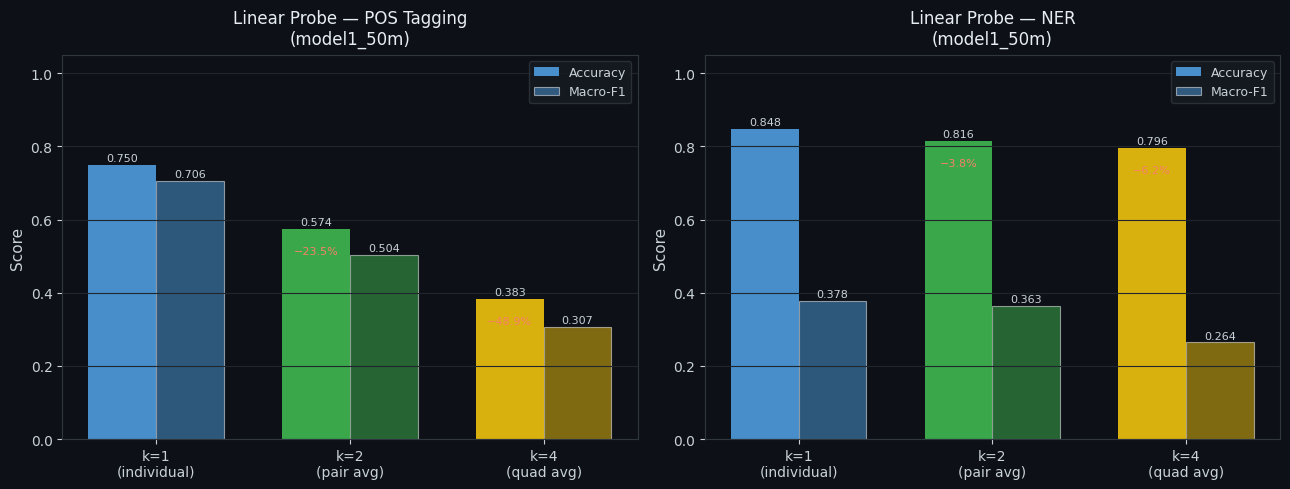

Saved → plots/linear_probe_results.png


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#0d1117")

COLORS = ["#4e9de0", "#3fb950", "#f1c40f"]   # k=1 blue, k=2 green, k=4 yellow
LABELS = ["k=1\n(individual)", "k=2\n(pair avg)", "k=4\n(quad avg)"]

for ax, (title, results) in zip(axes, [
    ("POS Tagging", [r_pos_1, r_pos_2, r_pos_4]),
    ("NER",         [r_ner_1, r_ner_2, r_ner_4]),
]):
    ax.set_facecolor("#0d1117")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.tick_params(colors="#c9d1d9")
    ax.yaxis.label.set_color("#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
    ax.title.set_color("#e6edf3")
    ax.grid(axis="y", color="#21262d", linewidth=0.8)

    accs  = [r["accuracy"]  for r in results]
    f1s   = [r["macro_f1"]  for r in results]
    x     = np.arange(len(LABELS))
    w     = 0.35

    bars_acc = ax.bar(x - w/2, accs, w, color=COLORS, alpha=0.9, label="Accuracy")
    bars_f1  = ax.bar(x + w/2, f1s,  w, color=COLORS, alpha=0.5, label="Macro-F1",
                      edgecolor="white", linewidth=0.8)

    # Annotate bars
    for bar, val in zip(list(bars_acc) + list(bars_f1), accs + f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8,
                color="#c9d1d9")

    # Drop percentage annotation
    for i in range(1, len(accs)):
        drop = (accs[0] - accs[i]) / accs[0] * 100
        ax.annotate(f"−{drop:.1f}%", xy=(x[i] - w/2, accs[i]),
                    xytext=(0, -18), textcoords="offset points",
                    ha="center", fontsize=8, color="#f78166")

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, color="#c9d1d9", fontsize=10)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Linear Probe — {title}\n({MODEL_NAME})", fontsize=12,
                 color="#e6edf3", pad=8)
    ax.legend(facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#c9d1d9", fontsize=9)

fig.tight_layout()
out = Path("./plots/linear_probe_results.png")
fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved → {out}")

## 6. Per-Class Breakdown (what categories are most affected?)

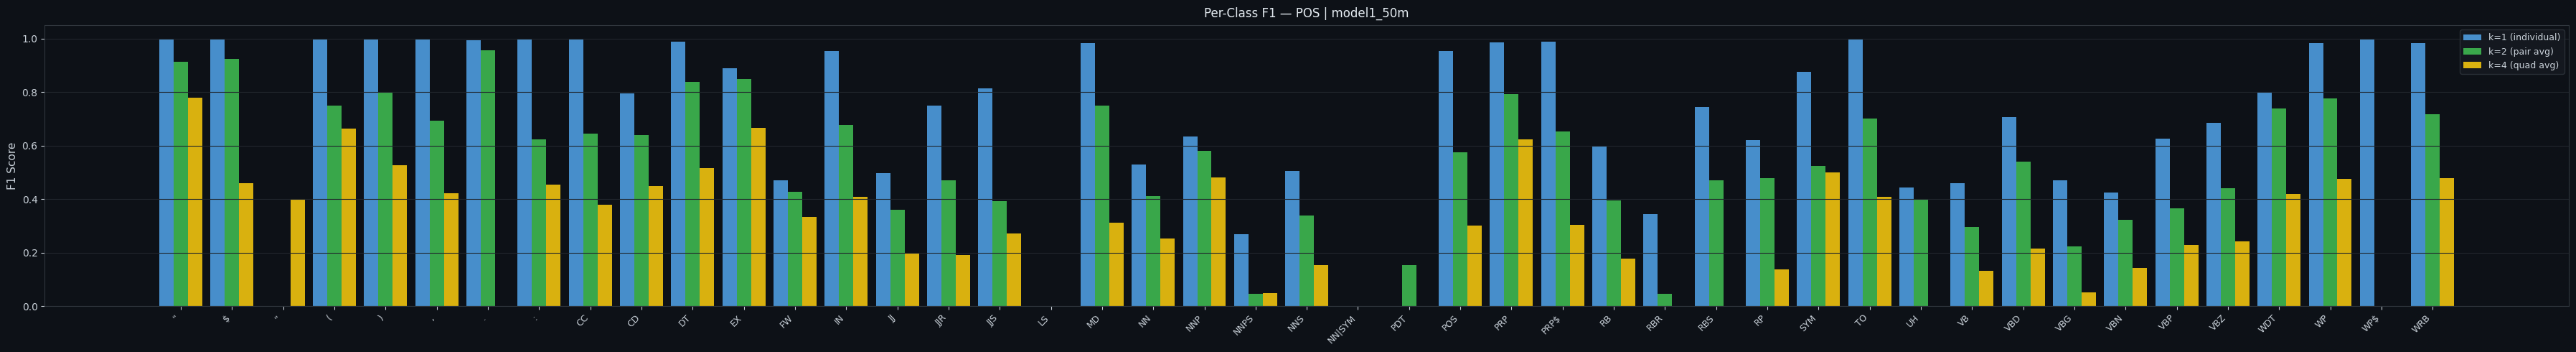

Saved → plots/linear_probe_pos_per_class.png


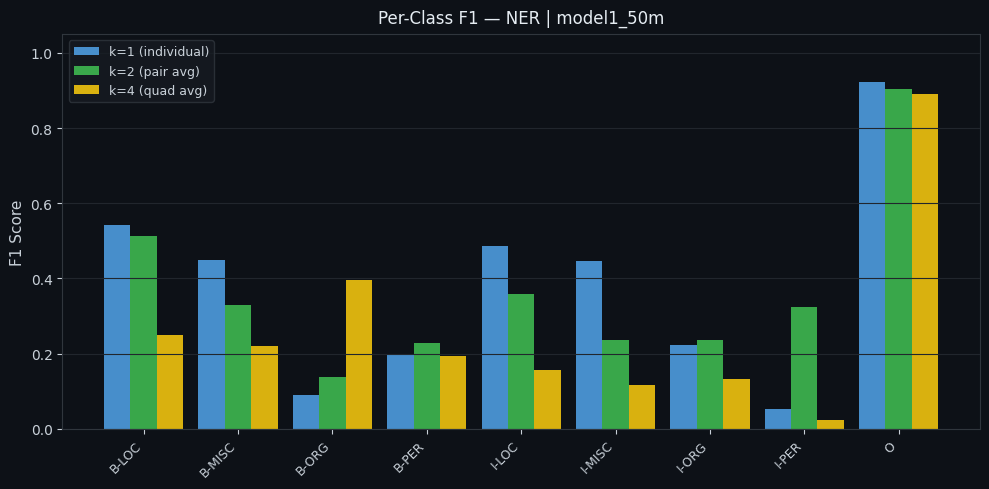

Saved → plots/linear_probe_ner_per_class.png


In [67]:
def per_class_f1(report: dict) -> dict:
    return {k: v["f1-score"] for k, v in report.items()
            if isinstance(v, dict) and k not in ("macro avg", "weighted avg")}

def plot_per_class(results_k1, results_k2, results_k4, task: str):
    f1_k1 = per_class_f1(results_k1["report"])
    f1_k2 = per_class_f1(results_k2["report"])
    f1_k4 = per_class_f1(results_k4["report"])

    classes = sorted(f1_k1.keys())
    x = np.arange(len(classes))

    fig, ax = plt.subplots(figsize=(max(10, len(classes)*0.8), 5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    for spine in ax.spines.values(): spine.set_edgecolor("#30363d")
    ax.tick_params(colors="#c9d1d9")
    ax.yaxis.label.set_color("#c9d1d9")
    ax.title.set_color("#e6edf3")
    ax.grid(axis="y", color="#21262d", linewidth=0.8)

    w = 0.28
    ax.bar(x - w,   [f1_k1.get(c, 0) for c in classes], w, color="#4e9de0", alpha=0.9, label="k=1 (individual)")
    ax.bar(x,       [f1_k2.get(c, 0) for c in classes], w, color="#3fb950", alpha=0.9, label="k=2 (pair avg)")
    ax.bar(x + w,   [f1_k4.get(c, 0) for c in classes], w, color="#f1c40f", alpha=0.9, label="k=4 (quad avg)")

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right", color="#c9d1d9", fontsize=9)
    ax.set_ylabel("F1 Score", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Class F1 — {task} | {MODEL_NAME}", fontsize=12,
                 color="#e6edf3", pad=8)
    ax.legend(facecolor="#161b22", edgecolor="#30363d",
              labelcolor="#c9d1d9", fontsize=9)
    fig.tight_layout()
    out = Path(f"./plots/linear_probe_{task.lower()}_per_class.png")
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"Saved → {out}")

plot_per_class(r_pos_1, r_pos_2, r_pos_4, "POS")
plot_per_class(r_ner_1, r_ner_2, r_ner_4, "NER")

## 7. Control: Random Embeddings Baseline
To interpret the results above, we need to know how much structure comes from training vs random initialisation.

In [68]:
d_model = cfg.d_model
random_emb = torch.randn(emb_matrix.shape[0], d_model) 

print("=== Random embeddings baseline ===")
print("POS:")
Xr_pos_1, yr_pos_1, Xr_ner_1, yr_ner_1 = extract_features("train",      random_emb, k=1, max_sentences=2000)
Xrv_pos_1, yrv_pos_1, Xrv_ner_1, yrv_ner_1 = extract_features("validation", random_emb, k=1, max_sentences=500)
r_rand_pos = train_probe(Xr_pos_1, yr_pos_1, Xrv_pos_1, yrv_pos_1, "POS (random emb)", k=1)
r_rand_ner = train_probe(Xr_ner_1, yr_ner_1, Xrv_ner_1, yrv_ner_1, "NER (random emb)", k=1)

print(f"\nSummary:")
print(f"  POS: random={r_rand_pos['accuracy']:.3f}  k=1={r_pos_1['accuracy']:.3f}  k=2={r_pos_2['accuracy']:.3f}  k=4={r_pos_4['accuracy']:.3f}")
print(f"  NER: random={r_rand_ner['accuracy']:.3f}  k=1={r_ner_1['accuracy']:.3f}  k=2={r_ner_2['accuracy']:.3f}  k=4={r_ner_4['accuracy']:.3f}")

=== Random embeddings baseline ===
POS:


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguou

  [POS (random emb) | k=1]  acc=0.735  macro-F1=0.657
  [NER (random emb) | k=1]  acc=0.805  macro-F1=0.374

Summary:
  POS: random=0.735  k=1=0.750  k=2=0.574  k=4=0.383
  NER: random=0.805  k=1=0.848  k=2=0.816  k=4=0.796


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 8. Multi-Model Comparison
Run the same probe across multiple trained models (standard vs averaging) to see if training objective changes embedding quality.

In [69]:
experiments = [
    ("model1_50m",  1),   # standard model, probe individually
    ("avg_50m_k2",  2),   # averaging model, probe as pairs
    ("avg_50m_k4",  4),   # averaging model, probe as quads
]
results_by_model = {}

for model_name, k in experiments:
    print(f"\n── {model_name} ──")
    try:
        emb = load_embedding_matrix(model_name, RESULTS_DIR)
    except Exception as e:
        print(f"  [skip] {e}")
        continue

    X_pos, y_pos, X_ner, y_ner = extract_features("train", emb, k=k)
    Xv_pos, yv_pos, Xv_ner, yv_ner = extract_features("validation", emb, k=k)

    rp = train_probe(X_pos, y_pos, Xv_pos, yv_pos, f"POS/{model_name}", k=k)
    rn = train_probe(X_ner, y_ner, Xv_ner, yv_ner, f"NER/{model_name}", k=k)
    results_by_model[model_name] = {"pos": rp, "ner": rn}


── model1_50m ──
ckpts: []
final: results/model1_50m/checkpoints/final.pt
ckpt_dir: results/model1_50m/checkpoints
Loading checkpoint: results/model1_50m/checkpoints/final.pt


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguou

  [POS/model1_50m | k=1]  acc=0.750  macro-F1=0.706


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguou

  [NER/model1_50m | k=1]  acc=0.848  macro-F1=0.378

── avg_50m_k2 ──
ckpts: []
final: results/avg_50m_k2/checkpoints/final.pt
ckpt_dir: results/avg_50m_k2/checkpoints
Loading checkpoint: results/avg_50m_k2/checkpoints/final.pt


...

/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


  [NER/avg_50m_k2 | k=2]  acc=0.825  macro-F1=0.409

── avg_50m_k4 ──
ckpts: []
final: results/avg_50m_k4/checkpoints/final.pt
ckpt_dir: results/avg_50m_k4/checkpoints
Loading checkpoint: results/avg_50m_k4/checkpoints/final.pt


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguou

  [POS/avg_50m_k4 | k=4]  acc=0.444  macro-F1=0.322
  [NER/avg_50m_k4 | k=4]  acc=0.819  macro-F1=0.321


/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/vardh/token-averaging/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


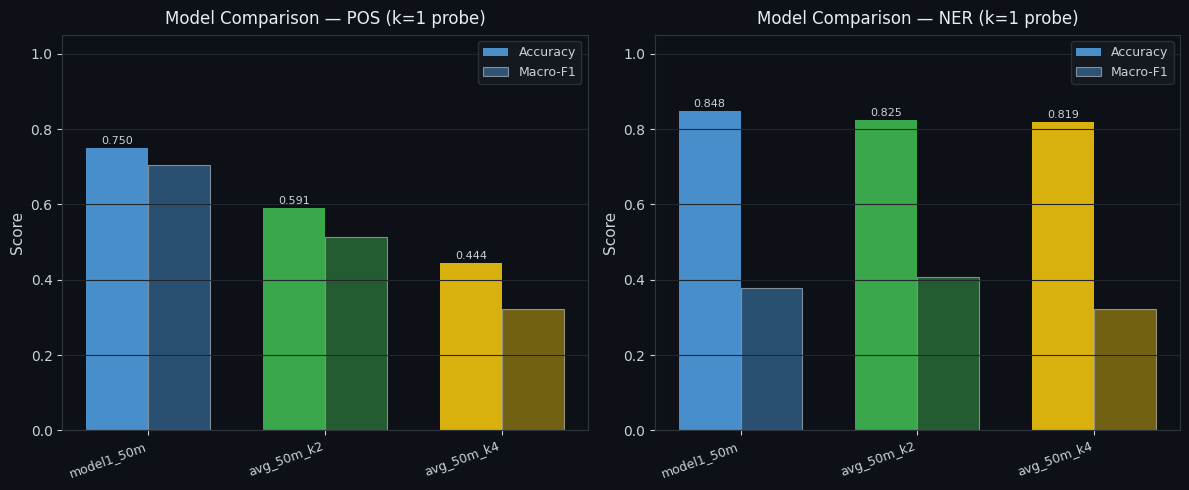

Saved → plots/linear_probe_model_comparison.png


In [70]:
if results_by_model:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#0d1117")
    MODEL_COLORS = ["#4e9de0", "#3fb950", "#f1c40f", "#00c8c8", "#9b59b6"]

    for ax, task in zip(axes, ["pos", "ner"]):
        ax.set_facecolor("#0d1117")
        for spine in ax.spines.values(): spine.set_edgecolor("#30363d")
        ax.tick_params(colors="#c9d1d9")
        ax.yaxis.label.set_color("#c9d1d9")
        ax.title.set_color("#e6edf3")
        ax.grid(axis="y", color="#21262d", linewidth=0.8)

        names = list(results_by_model.keys())
        accs  = [results_by_model[m][task]["accuracy"]  for m in names]
        f1s   = [results_by_model[m][task]["macro_f1"]  for m in names]
        x     = np.arange(len(names))
        w     = 0.35

        bars = ax.bar(x - w/2, accs, w, color=MODEL_COLORS[:len(names)], alpha=0.9, label="Accuracy")
        ax.bar(x + w/2, f1s, w, color=MODEL_COLORS[:len(names)], alpha=0.45, label="Macro-F1",
               edgecolor="white", linewidth=0.8)
        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8, color="#c9d1d9")

        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=20, ha="right", color="#c9d1d9", fontsize=9)
        ax.set_ylabel("Score", fontsize=11)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Model Comparison — {task.upper()} (k=1 probe)",
                     fontsize=12, color="#e6edf3", pad=8)
        ax.legend(facecolor="#161b22", edgecolor="#30363d",
                  labelcolor="#c9d1d9", fontsize=9)

    fig.tight_layout()
    out = Path("./plots/linear_probe_model_comparison.png")
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"Saved → {out}")

## 9. Bonus: Nearest Neighbour Analysis
For each averaged embedding, find the nearest vocabulary token — does the average land somewhere semantically meaningful?

In [71]:
from sklearn.metrics.pairwise import cosine_similarity

EMB = emb_matrix.numpy()  # [vocab, d_model]
# Normalise for cosine
EMB_norm = EMB / (np.linalg.norm(EMB, axis=1, keepdims=True) + 1e-9)

EXAMPLES = [
    ("London", "Paris"),
    ("the",    "cat"),
    ("un",     "believable"),
    ("New",    "York"),
    ("good",   "bad"),
    ("is",     "running"),
]

print(f"{'Word 1':<15} {'Word 2':<15} {'Nearest to avg':<20} {'Cosine sim':>12}")
print("-" * 65)

for w1, w2 in EXAMPLES:
    e1 = word_embedding(w1, emb_matrix)
    e2 = word_embedding(w2, emb_matrix)
    avg = (e1 + e2) / 2
    avg_norm = avg / (np.linalg.norm(avg) + 1e-9)

    sims = EMB_norm @ avg_norm                    # [vocab]
    top5 = np.argsort(sims)[::-1][:5]
    nearest_tok = tokenizer.decode([top5[0]]).strip()
    sim_val     = sims[top5[0]]

    print(f"{w1:<15} {w2:<15} {nearest_tok:<20} {sim_val:>12.4f}")

Word 1          Word 2          Nearest to avg         Cosine sim
-----------------------------------------------------------------
London          Paris           Paris                      0.6947
the             cat             the                        0.7010
un              believable      un                         0.7987
New             York            York                       0.7384
good            bad             bad                        0.7343
is              running         is                         0.7224


/var/folders/df/t9cn2q3s5bv415v50tksnk1c0000gn/T/ipykernel_2449/2549065793.py:25: RuntimeWarning: divide by zero encountered in matmul
  sims = EMB_norm @ avg_norm                    # [vocab]
/var/folders/df/t9cn2q3s5bv415v50tksnk1c0000gn/T/ipykernel_2449/2549065793.py:25: RuntimeWarning: overflow encountered in matmul
  sims = EMB_norm @ avg_norm                    # [vocab]
/var/folders/df/t9cn2q3s5bv415v50tksnk1c0000gn/T/ipykernel_2449/2549065793.py:25: RuntimeWarning: invalid value encountered in matmul
  sims = EMB_norm @ avg_norm                    # [vocab]


## 10. Summary Table

In [72]:
print("=" * 65)
print(f"MODEL: {MODEL_NAME}")
print("=" * 65)
print(f"{'Condition':<25} {'POS Acc':>9} {'POS F1':>9} {'NER Acc':>9} {'NER F1':>9}")
print("-" * 65)

rows = [
    ("Random embeddings",  r_rand_pos, r_rand_ner),
    ("k=1 (individual)",   r_pos_1,    r_ner_1),
    ("k=2 (pair avg)",     r_pos_2,    r_ner_2),
    ("k=4 (quad avg)",     r_pos_4,    r_ner_4),
]
for label, rp, rn in rows:
    print(f"{label:<25} {rp['accuracy']:>9.3f} {rp['macro_f1']:>9.3f} "
          f"{rn['accuracy']:>9.3f} {rn['macro_f1']:>9.3f}")

print("=" * 65)
print()
drop_pos_k2 = (r_pos_1['accuracy'] - r_pos_2['accuracy']) / r_pos_1['accuracy'] * 100
drop_pos_k4 = (r_pos_1['accuracy'] - r_pos_4['accuracy']) / r_pos_1['accuracy'] * 100
print(f"POS accuracy drop:  k=1→k=2: {drop_pos_k2:.1f}%   k=1→k=4: {drop_pos_k4:.1f}%")
drop_ner_k2 = (r_ner_1['accuracy'] - r_ner_2['accuracy']) / r_ner_1['accuracy'] * 100
drop_ner_k4 = (r_ner_1['accuracy'] - r_ner_4['accuracy']) / r_ner_1['accuracy'] * 100
print(f"NER accuracy drop:  k=1→k=2: {drop_ner_k2:+.1f}%   k=1→k=4: {drop_ner_k4:+.1f}%")
print()
print("Interpretation:")
print("  Small drop (<5%)  → averaging preserves most linguistic structure")
print("  Large drop (>15%) → averaging loses significant structure")
print("  ~= random         → trained embeddings encode very little structure")

MODEL: model1_50m
Condition                   POS Acc    POS F1   NER Acc    NER F1
-----------------------------------------------------------------
Random embeddings             0.735     0.657     0.805     0.374
k=1 (individual)              0.750     0.706     0.848     0.378
k=2 (pair avg)                0.574     0.504     0.816     0.363
k=4 (quad avg)                0.383     0.307     0.796     0.264

POS accuracy drop:  k=1→k=2: 23.5%   k=1→k=4: 48.9%
NER accuracy drop:  k=1→k=2: +3.8%   k=1→k=4: +6.2%

Interpretation:
  Small drop (<5%)  → averaging preserves most linguistic structure
  Large drop (>15%) → averaging loses significant structure
  ~= random         → trained embeddings encode very little structure
